In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from pathlib import Path
from Models.LSTM import TwoLayerLSTM

In [2]:
project_root = Path.cwd().parent  # Go up one level from /notebooks/ to the project root
data_path = project_root / "Data" / "Processed Data" / "AirQualityUCI_cleaned.csv"

# --- Load the Dataset ---
df = pd.read_csv(data_path)

# Features 
X = df[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 
        'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

# Target 
y = df['C6H6(GT)']  # benzene concentration

# --- Preview the Data ---
df.head()

,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,1360.00,11.881723,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,1292.25,9.397165,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,1402.00,8.997817,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,1375.50,9.228796,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1272.25,6.518224,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
SEED = 42
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

In [4]:
scaler_X = StandardScaler()
x_train = scaler_X.fit_transform(x_train)
x_val   = scaler_X.transform(x_val)
x_test  = scaler_X.transform(x_test)

In [5]:
y_train = y_train.to_numpy().reshape(-1, 1)
y_val   = y_val.to_numpy().reshape(-1, 1)
y_test  = y_test.to_numpy().reshape(-1, 1)

In [6]:
SEQ_LEN = 10

def create_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(len(X) - seq_len):
        xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])  # predict next step
    return np.array(xs), np.array(ys)

x_train_seq, y_train_seq = create_sequences(x_train, y_train, SEQ_LEN)
x_val_seq, y_val_seq     = create_sequences(x_val, y_val, SEQ_LEN)
x_test_seq, y_test_seq   = create_sequences(x_test, y_test, SEQ_LEN)

In [7]:
x_train_seq = torch.tensor(x_train_seq, dtype=torch.float32)
y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32)
x_val_seq   = torch.tensor(x_val_seq, dtype=torch.float32)
y_val_seq   = torch.tensor(y_val_seq, dtype=torch.float32)
x_test_seq  = torch.tensor(x_test_seq, dtype=torch.float32)
y_test_seq  = torch.tensor(y_test_seq, dtype=torch.float32)

In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(TensorDataset(x_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = x_train_seq.shape[2]
hidden_size = 128
num_epochs = 20
lr = 0.001

In [10]:
model = TwoLayerLSTM(input_size=input_size, hidden_size=hidden_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [11]:
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_x, val_y in val_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_outputs = model(val_x)
            val_loss += criterion(val_outputs, val_y).item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch [1/20] - Train Loss: 61.4150, Val Loss: 60.2562
Epoch [2/20] - Train Loss: 50.2879, Val Loss: 40.6221
Epoch [3/20] - Train Loss: 11.7253, Val Loss: 7.4059
Epoch [4/20] - Train Loss: 3.6989, Val Loss: 3.7087
Epoch [5/20] - Train Loss: 1.9950, Val Loss: 2.2081
Epoch [6/20] - Train Loss: 1.2274, Val Loss: 1.4184
Epoch [7/20] - Train Loss: 0.8315, Val Loss: 0.9710
Epoch [8/20] - Train Loss: 0.6042, Val Loss: 0.7188
Epoch [9/20] - Train Loss: 0.4749, Val Loss: 0.6024
Epoch [10/20] - Train Loss: 0.3798, Val Loss: 0.5555
Epoch [11/20] - Train Loss: 0.3184, Val Loss: 0.3800
Epoch [12/20] - Train Loss: 0.2733, Val Loss: 0.3309
Epoch [13/20] - Train Loss: 0.2439, Val Loss: 0.2909
Epoch [14/20] - Train Loss: 0.2212, Val Loss: 0.2788
Epoch [15/20] - Train Loss: 0.1947, Val Loss: 0.2342
Epoch [16/20] - Train Loss: 0.1729, Val Loss: 0.1992
Epoch [17/20] - Train Loss: 0.1669, Val Loss: 0.1773
Epoch [18/20] - Train Loss: 0.1500, Val Loss: 0.1773
Epoch [19/20] - Train Loss: 0.1403, Val Loss: 0.14

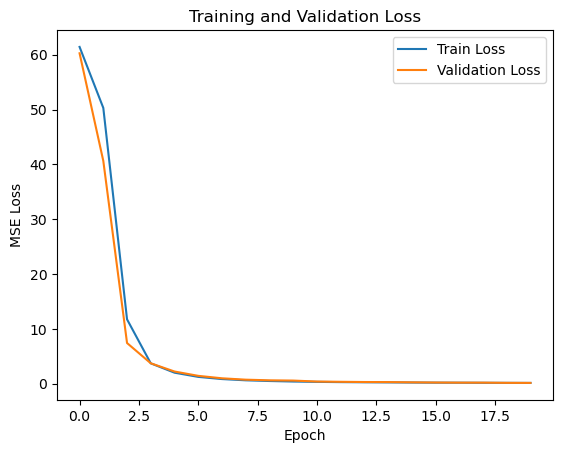

In [12]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

Test RMSE: 0.3225


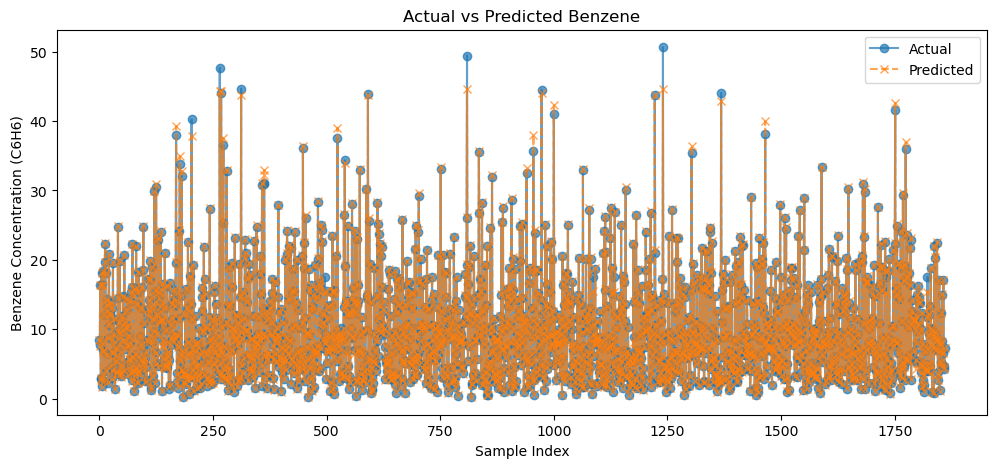

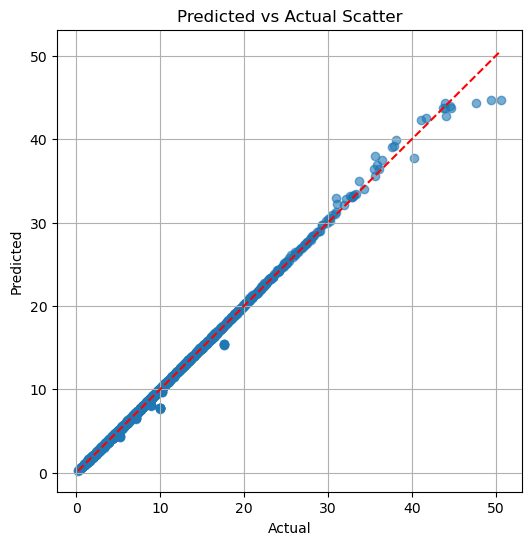

In [13]:
model.eval()
y_preds, y_trues = [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        pred = model(x_batch)
        y_preds.append(pred)
        y_trues.append(y_batch)

# Concatenate all batches
y_pred_tensor = torch.cat(y_preds).cpu()
y_true_tensor = torch.cat(y_trues).cpu()

# RMSE
rmse = torch.sqrt(torch.mean((y_pred_tensor - y_true_tensor)**2))
print(f"Test RMSE: {rmse.item():.4f}")

# Plot: Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(y_true_tensor.numpy(), label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred_tensor.numpy(), label="Predicted", marker='x', linestyle='--', alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("Benzene Concentration (C6H6)")
plt.title("Actual vs Predicted Benzene")
plt.legend()
plt.show()

# Optional: Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_true_tensor.numpy(), y_pred_tensor.numpy(), alpha=0.6)
plt.plot([y_true_tensor.min(), y_true_tensor.max()],
         [y_true_tensor.min(), y_true_tensor.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Scatter")
plt.grid(True)
plt.show()
